<a href="https://colab.research.google.com/github/Chandhana-sanoj/ICT_DSA_2026/blob/main/Regression_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#import libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# EDA

In [6]:
df = pd.read_csv('/content/auto-mpg.csv')

In [7]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [8]:
df.isna().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


#Cleaning

In [12]:
df['horsepower'].unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

In [13]:
df.replace('?', np.nan, inplace=True)
df['horsepower'] = pd.to_numeric(df['horsepower'])
df.dropna(inplace=True)

#Splitting numerical and categorical columns

In [14]:
num_df = df.select_dtypes(include=['number'])
cat_df = df.select_dtypes(include=['object'])

num_cols = num_df.columns.tolist()
cat_cols = cat_df.columns.tolist()

In [15]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [16]:
num_cols

['mpg',
 'cylinders',
 'displacement',
 'horsepower',
 'weight',
 'acceleration',
 'model year',
 'origin']

In [17]:
cat_cols

['car name']

#Encoding of categorical columns

In [18]:
cat_df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

#Merge numerical and categorical columns

In [19]:
final_df = pd.concat([num_df, cat_df], axis=1)

##Separate Features and labels

In [20]:
y = final_df['mpg']
X = final_df.drop('mpg', axis=1)

#Train-test split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

#Modeling

In [22]:
reg_lin = LinearRegression()
reg_lin.fit(X_train, y_train)
y_pred = reg_lin.predict(X_test)

#Model Evaluation

In [31]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Square Error: {mse}")
print(f"R-squared: {r2}")

Mean Square Error: 16.96229713930782
R-squared: 0.667670389666328


In [32]:
result_df = pd.DataFrame()
result_df['Model'] = ['Linear Regression']
result_df['MSE'] = [mse]
result_df['R2 Score'] = [r2]

result_df

,Model,MSE,R2 Score
0,Linear Regression,16.962297,0.66767


#Compare Actual vs Predicted

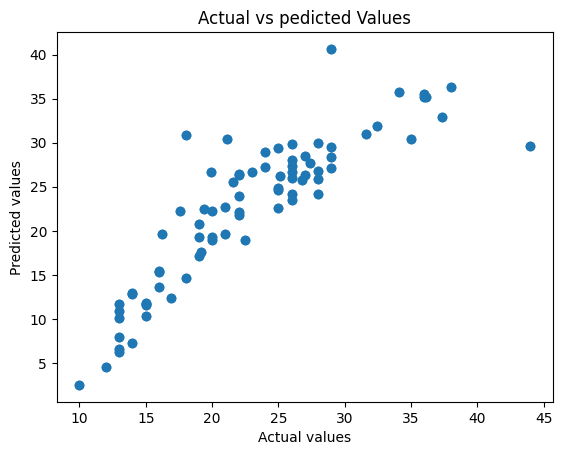

In [26]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Actual vs pedicted Values')
plt.show()

#Ridge Regression

In [27]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train,y_train)
ridge_pred= ridge.predict(X_test)

In [33]:
mse_ridge = mean_squared_error(y_test, ridge_pred)
r2_ridge = r2_score(y_test, ridge_pred)

print(f"Mean Square Error: {mse}")
print(f"R-squared: {r2}")

Mean Square Error: 16.96229713930782
R-squared: 0.667670389666328


#Lasso Regression

In [28]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train,y_train)
lasso_pred = lasso.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.461e+02, tolerance: 1.975e+00
  model = cd_fast.enet_coordinate_descent(


In [34]:
mse_lasso = mean_squared_error(y_test, lasso_pred)
r2_lasso = r2_score(y_test, lasso_pred)

print(f"Mean Square Error: {mse}")
print(f"R-squared: {r2}")

Mean Square Error: 16.96229713930782
R-squared: 0.667670389666328


In [35]:
result_df = pd.DataFrame()
result_df['Model'] = ['Linear Regression','Ridge Regression', 'Lasso Regression']
result_df['MSE'] = [mse, mse_ridge, mse_lasso]
result_df['R2 Score'] = [r2,r2_ridge,r2_lasso]

result_df

,Model,MSE,R2 Score
0,Linear Regression,16.962297,0.667670
1,Ridge Regression,11.278030,0.779038
2,Lasso Regression,10.753200,0.789321
